In [ ]:
!pip install -q torch numpy scikit-learn matplotlib onnx onnxruntime onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 10.4 MB/s eta 0:00:00


## Install libraries fro CNN1D Log Sentinel Model

In [ ]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
import os

In [ ]:
DRIVE_ROOT = "/content/drive/MyDrive/Aegis-CyberSec-Guard"
DATA_DIR = os.path.join(DRIVE_ROOT, "logsentinel", "dataV1")

In [ ]:
LOCAL_DIR = "/content/logsentinel_train"
CKPT_DIR = os.path.join(LOCAL_DIR, "checkpoints")

In [ ]:
DRIVE_OUT = os.path.join(DRIVE_ROOT, "logsentinel", "modelV2")


In [ ]:
EMBED_DIM = 32
KERNEL_SIZES = (3, 5, 7)

##  Set Global CONSTANTS

In [ ]:
NUM_FILTERS = 128  # per branch
DROPOUT = 0.3
HIDDEN_DIM = 128
BATCH_SIZE = 1024   # tiny model, large batches are free and fast
NUM_EPOCHS = 12
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
EARLY_STOP_PATIENCE = 4  # epochs without val PR-AUC improvement before stopping
POS_WEIGHT = None
FBETA = 2. # F2: recall weighted 2x. SOC bias: missed intrusion > false alarm.
SEED = 3407

In [ ]:
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Reading tensors from: {DATA_DIR}")
print(f"Local work dir:       {LOCAL_DIR}")
print(f"Final artifacts to:   {DRIVE_OUT}")

Reading tensors from: /content/drive/MyDrive/Aegis-CyberSec-Guard/logsentinel/dataV1
Local work dir:       /content/logsentinel_train
Final artifacts to:   /content/drive/MyDrive/Aegis-CyberSec-Guard/logsentinel/modelV2


In [ ]:
import json
import random
import shutil
import time


## Import ML Libraries

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader


In [ ]:
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    fbeta_score,
    confusion_matrix,
)

In [ ]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: Tesla T4


## Load tensors and metadata from the ETL


In [ ]:
X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
y_train = np.load(os.path.join(DATA_DIR, "y_train.npy"))
X_val = np.load(os.path.join(DATA_DIR, "X_val.npy"))
y_val = np.load(os.path.join(DATA_DIR, "y_val.npy"))
X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))

with open(os.path.join(DATA_DIR, "metadata.json")) as f:
    etl_meta = json.load(f)

VOCAB_SIZE = etl_meta["vocab_size"]
MAX_SEQ_LEN = etl_meta["max_seq_len"]
PAD_VALUE = etl_meta["pad_value"]

print(f"vocab_size: {VOCAB_SIZE} | max_seq_len: {MAX_SEQ_LEN} | pad: {PAD_VALUE}")
for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    print(f"{name}: X{X.shape} y{y.shape} | anomalies {int(y.sum())} ({100*y.mean():.2f}%)")


vocab_size: 31 | max_seq_len: 40 | pad: 0
train: X(415480, 40) y(415480,) | anomalies 12165 (2.93%)
val: X(73321, 40) y(73321,) | anomalies 2147 (2.93%)
test: X(86260, 40) y(86260,) | anomalies 2526 (2.93%)


## Sanity Check

In [ ]:
# ETL provided event IDs within the vocab and binary labels.
assert X_train.max() < VOCAB_SIZE, "event ID exceeds vocab size"
assert set(np.unique(y_train)).issubset({0, 1}), "labels must be binary"


##  DataLoaders

In [ ]:
# int64 for the embedding lookup, float32 for BCEWithLogitsLoss targets.

def make_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(
        torch.from_numpy(X).long(),
        torch.from_numpy(y).float().unsqueeze(1),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=2, pin_memory=True)


In [ ]:
train_loader = make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_val, y_val, BATCH_SIZE, shuffle=False)
test_loader = make_loader(X_test, y_test, BATCH_SIZE, shuffle=False)

In [ ]:
print(f"train batches: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

train batches: 406 | val: 72 | test: 85


## Model definition
Classic TextCNN x1D

In [ ]:
## Set the model from torch.nn.Modules
class LogSentinel(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=EMBED_DIM,
        kernel_sizes=KERNEL_SIZES,
        num_filters=NUM_FILTERS,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
        pad_idx=PAD_VALUE,
    ):
        super().__init__()

        # padding_idx freezes the pad vector at zero with no gradient.
        # Without it the model would learn an embedding for "filler", which is nonsense.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        # Parallel branches, not stacked: each one scans the whole sequence at its own
        # n-gram scale. k=3 catches local triplets, k=7 catches phase-level motifs.
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim,
                      out_channels=num_filters,
                      kernel_size=k)
            for k in kernel_sizes
        ])
        # nn.Embedding returns (batch, length, dim)
        # nn.Conv1d expects  (batch, channels, length)
        concat_dim = num_filters * len(kernel_sizes)

        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(concat_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
    # the embedding dim must become the channel dim before convolving.
    def forward(self, x):
        # x: (batch, seq_len) int64
        emb = self.embedding(x)  # (batch, seq_len, embed_dim)
        emb = emb.permute(0, 2, 1) # (batch, embed_dim, seq_len)  <- the gotcha

        # Global MAX pool (not average): an anomaly is the PRESENCE of a bad motif
        # somewhere in the session, not an average property of it.
        pooled = []
        for conv in self.convs:
            h = F.relu(conv(emb)) # (batch, num_filters, seq_len - k + 1)
            h = F.max_pool1d(h, kernel_size=h.shape[2]).squeeze(2)   # (batch, num_filters)
            pooled.append(h)

        h = torch.cat(pooled, dim=1)   # (batch, num_filters * len(kernels))
        h = self.dropout(h)
        h = F.relu(self.fc1(h))
        h = self.dropout(h)
        # (batch, 1) raw logits, no sigmoid here
        return self.fc2(h)


In [ ]:
model = LogSentinel(vocab_size=VOCAB_SIZE).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nTrainable parameters: {n_params:,}")
print(f"Approx size in fp32: {n_params * 4 / 1e6:.2f} MB")


LogSentinel(
  (embedding): Embedding(31, 32, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(32, 128, kernel_size=(3,), stride=(1,))
    (1): Conv1d(32, 128, kernel_size=(5,), stride=(1,))
    (2): Conv1d(32, 128, kernel_size=(7,), stride=(1,))
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

Trainable parameters: 112,225
Approx size in fp32: 0.45 MB


## Shape check before training
Push one batch through. Shape bugs are free to catch here, expensive to catch at epoch 3.


In [ ]:
xb, yb = next(iter(train_loader))
print(f"input batch:  {tuple(xb.shape)}  dtype={xb.dtype}")
with torch.no_grad():
    out = model(xb.to(DEVICE))
print(f"output batch: {tuple(out.shape)}  dtype={out.dtype}")
assert out.shape == (xb.shape[0], 1), "unexpected output shape"
print("Shape check passed.")

input batch:  (1024, 40)  dtype=torch.int64
output batch: (1024, 1)  dtype=torch.float32
Shape check passed.


## Set Loss, optimizer, scheduler

BCEWithLogitsLoss (not Sigmoid + BCELoss): numerically stable by log-sum-exp,and pos_weight only exists on the logits variant.
pos_weight multiplies the loss on positive examples, so a false negative hurts~33x more than a false positive .

In [ ]:
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
computed_pos_weight = n_neg / n_pos

In [ ]:
pos_weight_value = POS_WEIGHT if POS_WEIGHT is not None else computed_pos_weight
pos_weight = torch.tensor([pos_weight_value], device=DEVICE)

In [ ]:
print(f"negatives: {n_neg} | positives: {n_pos}")
print(f"computed pos_weight (n_neg/n_pos): {computed_pos_weight:.2f}")
print(f"using pos_weight: {pos_weight_value:.2f}")

negatives: 403315 | positives: 12165
computed pos_weight (n_neg/n_pos): 33.15
using pos_weight: 33.15


## Define Training Criterion

In [ ]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

## Set Evaluation helper

 Returns raw probabilities so the threshold can be chosen afterwards PR-AUC (average_precision_score) is threshold-free and focuses on the positive class. ROC-AUC is deliberately not used: with 97% negatives the FPR axis collapses and
 ROC-AUC might reports ~0.98 for mediocre models.

In [ ]:

@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    probs, targets = [], []
    for xb, yb in loader:
        logits = model(xb.to(DEVICE))
        probs.append(torch.sigmoid(logits).cpu().numpy())   # sigmoid only at inference
        targets.append(yb.numpy())

    return np.vstack(probs).ravel(), np.vstack(targets).ravel()


@torch.no_grad()
def eval_loss(model, loader):
    model.eval()
    total, n = 0.0, 0
    for xb, yb in loader:
        logits = model(xb.to(DEVICE))
        loss = criterion(logits, yb.to(DEVICE))
        total += loss.item() * xb.shape[0]
        n += xb.shape[0]

    return total / n


##  Training loop

In [ ]:
# Checkpoints go to LOCAL disk. Best model selected by validation PR-AUC.

history = {"train_loss": [], "val_loss": [], "val_pr_auc": []}
best_pr_auc = -1.0
best_epoch = -1
epochs_without_improvement = 0
best_ckpt_path = os.path.join(CKPT_DIR, "logsentinel_best.pt")


In [ ]:

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running, seen = 0.0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.shape[0]
        seen += xb.shape[0]

    train_loss = running / seen
    val_loss_value = eval_loss(model, val_loader)
    val_probs, val_targets = predict_probs(model, val_loader)
    val_pr_auc = average_precision_score(val_targets, val_probs)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss_value)
    history["val_pr_auc"].append(val_pr_auc)

    scheduler.step(val_pr_auc)

    marker = ""
    if val_pr_auc > best_pr_auc:
        best_pr_auc = val_pr_auc
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_ckpt_path)
        marker = "  <- best, saved"
    else:
        epochs_without_improvement += 1

    lr_now = optimizer.param_groups[0]["lr"]
    print(
        f"epoch {epoch:2d}/{NUM_EPOCHS} | train {train_loss:.4f} | val {val_loss_value:.4f} "
        f"| val PR-AUC {val_pr_auc:.4f} | lr {lr_now:.2e}{marker}"
    )

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping: no val PR-AUC improvement for {EARLY_STOP_PATIENCE} epochs.")
        break

elapsed = time.time() - start_time
print(f"\nTraining finished in {elapsed/60:.1f} min")
print(f"Best epoch: {best_epoch} | best val PR-AUC: {best_pr_auc:.4f}")


epoch  1/12 | train 0.0886 | val 0.0076 | val PR-AUC 0.9947 | lr 1.00e-03  <- best, saved
epoch  2/12 | train 0.0095 | val 0.0053 | val PR-AUC 0.9985 | lr 1.00e-03  <- best, saved
epoch  3/12 | train 0.0084 | val 0.0057 | val PR-AUC 0.9991 | lr 1.00e-03  <- best, saved
epoch  4/12 | train 0.0060 | val 0.0049 | val PR-AUC 0.9996 | lr 1.00e-03  <- best, saved
epoch  5/12 | train 0.0058 | val 0.0040 | val PR-AUC 0.9995 | lr 1.00e-03
epoch  6/12 | train 0.0057 | val 0.0042 | val PR-AUC 0.9989 | lr 1.00e-03
epoch  7/12 | train 0.0049 | val 0.0036 | val PR-AUC 0.9997 | lr 1.00e-03  <- best, saved
epoch  8/12 | train 0.0050 | val 0.0045 | val PR-AUC 0.9996 | lr 1.00e-03
epoch  9/12 | train 0.0047 | val 0.0036 | val PR-AUC 0.9998 | lr 1.00e-03  <- best, saved
epoch 10/12 | train 0.0049 | val 0.0034 | val PR-AUC 0.9998 | lr 5.00e-04
epoch 11/12 | train 0.0044 | val 0.0032 | val PR-AUC 0.9998 | lr 5.00e-04
epoch 12/12 | train 0.0036 | val 0.0034 | val PR-AUC 0.9999 | lr 5.00e-04  <- best, saved


In [ ]:
# Load the best weights, not the last ones.
model.load_state_dict(torch.load(best_ckpt_path))
print("Loaded best checkpoint.")


Loaded best checkpoint.


## Threshold selection on VALIDATION  

In [ ]:
val_probs, val_targets = predict_probs(model, val_loader)
precisions, recalls, thresholds = precision_recall_curve(val_targets, val_probs)

In [ ]:
# precision_recall_curve returns len(thresholds) == len(precisions) - 1
beta2 = FBETA ** 2
f_beta = (
    (1 + beta2) * precisions[:-1] * recalls[:-1]
    / np.clip(beta2 * precisions[:-1] + recalls[:-1], 1e-12, None)
)
# being carefull with the  training results

In [ ]:

best_idx = int(np.nanargmax(f_beta))
BEST_THRESHOLD = float(thresholds[best_idx])


In [ ]:

print(f"Selected threshold (max F{FBETA:.0f} on validation): {BEST_THRESHOLD:.4f}")
print(f"  at that point -> precision {precisions[best_idx]:.4f} | recall {recalls[best_idx]:.4f} "
      f"| F{FBETA:.0f} {f_beta[best_idx]:.4f}")
print(f"  (default 0.5 would have been arbitrary here)")


Selected threshold (max F2 on validation): 0.9744
  at that point -> precision 0.9926 | recall 0.9991 | F2 0.9978
  (default 0.5 would have been arbitrary here)


## Final evaluation on TEST with the frozen threshold

In [ ]:
# Accuracy is intentionally absent: with 97.07% negatives it is meaningless.

test_probs, test_targets = predict_probs(model, test_loader)
test_preds = (test_probs >= BEST_THRESHOLD).astype(int)


In [ ]:
# Assess the Model in Test Set
test_pr_auc = average_precision_score(test_targets, test_probs)
test_precision = precision_score(test_targets, test_preds, zero_division=0)
test_recall = recall_score(test_targets, test_preds, zero_division=0)
test_f1 = fbeta_score(test_targets, test_preds, beta=1.0, zero_division=0)
test_f2 = fbeta_score(test_targets, test_preds, beta=2.0, zero_division=0)


In [ ]:
tn, fp, fn, tp = confusion_matrix(test_targets, test_preds).ravel()


In [ ]:

print("TEST RESULTS (threshold frozen from validation)")
print(f"  PR-AUC:    {test_pr_auc:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1:        {test_f1:.4f}")
print(f"  F2:        {test_f2:.4f}")
print()
print("Confusion matrix:")
print(f"  TN {tn:>7}   FP {fp:>7}")
print(f"  FN {fn:>7}   TP {tp:>7}")
print()
print(f"  Missed anomalies (FN): {fn} of {tp+fn} ({100*fn/(tp+fn):.2f}%)")
print(f"  False alarms (FP):     {fp} — analyst reviews this many normal blocks")



=== TEST RESULTS (threshold frozen from validation) ===
  PR-AUC:    0.9978
  Precision: 0.9906
  Recall:    0.9968
  F1:        0.9937
  F2:        0.9956

Confusion matrix:
  TN   83710   FP      24
  FN       8   TP    2518

  Missed anomalies (FN): 8 of 2526 (0.32%)
  False alarms (FP):     24 — analyst reviews this many normal blocks


In [ ]:
## Plot Training Curves

import matplotlib.pyplot as plt


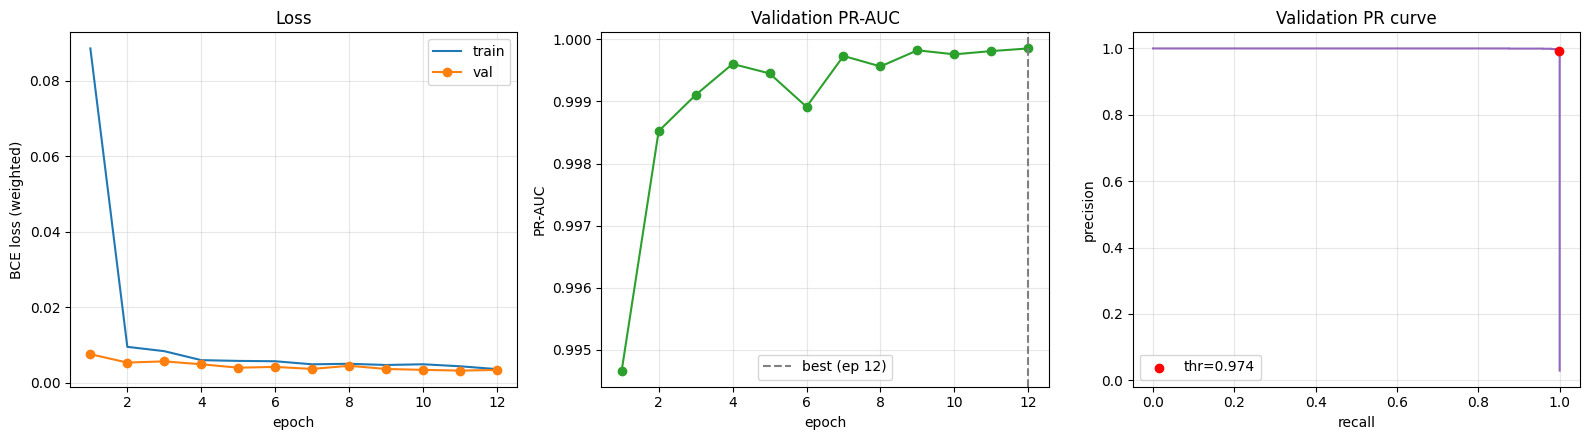

Saved: /content/logsentinel_train/logsentinel_curves.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

epochs_ran = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_ran, history["train_loss"], label="train")
axes[0].plot(epochs_ran, history["val_loss"], label="val", marker="o")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE loss (weighted)")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history["val_pr_auc"], marker="o", color="tab:green")
axes[1].axvline(best_epoch, ls="--", c="gray", label=f"best (ep {best_epoch})")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("PR-AUC")
axes[1].set_title("Validation PR-AUC"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(recalls, precisions, color="tab:purple")
axes[2].scatter([recalls[best_idx]], [precisions[best_idx]], c="red", zorder=5,
                label=f"thr={BEST_THRESHOLD:.3f}")
axes[2].set_xlabel("recall"); axes[2].set_ylabel("precision")
axes[2].set_title("Validation PR curve"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(LOCAL_DIR, "logsentinel_curves.png")
plt.savefig(plot_path, dpi=120)
plt.show()
print(f"Saved: {plot_path}")


## Export to ONNX for CPU inference

In [ ]:
# This is what runs inside the FastAPI backend on the existing EC2, on CPU, in
# milliseconds — never touching the GPU my other vision models are using.
model.eval()
model_cpu = LogSentinel(vocab_size=VOCAB_SIZE)
model_cpu.load_state_dict(torch.load(best_ckpt_path, map_location="cpu"))
model_cpu.eval()

LogSentinel(
  (embedding): Embedding(31, 32, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(32, 128, kernel_size=(3,), stride=(1,))
    (1): Conv1d(32, 128, kernel_size=(5,), stride=(1,))
    (2): Conv1d(32, 128, kernel_size=(7,), stride=(1,))
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

In [ ]:
dummy = torch.randint(low=0, high=VOCAB_SIZE, size=(1, MAX_SEQ_LEN), dtype=torch.long)
onnx_path = os.path.join(LOCAL_DIR, "logsentinel.onnx")


In [ ]:
torch.onnx.export(
    model_cpu, dummy, "logsentinel.onnx",
    input_names=["event_sequence"], output_names=["logit"],
    dynamic_axes={"event_sequence": {0: "batch"}, "logit": {0: "batch"}},
    opset_version=17,
    export_params=True,
    dynamo=False,
) ## did nto work, \n try it again

/tmp/ipykernel_478/1406889760.py:1: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


In [ ]:
## First ONNX Export Failed,  R-Attempt again with torch.onnx_export

In [ ]:
torch.onnx.export(
    model_cpu,
    dummy,
    onnx_path,
    input_names=["event_sequence"],
    output_names=["logit"],
    dynamic_axes={"event_sequence": {0: "batch"}, "logit": {0: "batch"}},
    opset_version=18,
    export_params=True,
    do_constant_folding=True,
)

In [ ]:
print(f"Exported: {onnx_path} ({os.path.getsize(onnx_path)/1e6:.2f} MB)")

Exported: /content/logsentinel_train/logsentinel.onnx (0.45 MB)


In [ ]:
# check it works \n I do not trust this things at frists
import onnxruntime as ort


In [ ]:
session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])

In [ ]:
sample = X_test[:256].astype(np.int64)
onnx_logits = session.run(None, {"event_sequence": sample})[0].ravel()
onnx_probs = 1.0 / (1.0 + np.exp(-onnx_logits))

In [ ]:
with torch.no_grad():
    torch_logits = model_cpu(torch.from_numpy(sample)).numpy().ravel()

torch_probs = 1.0 / (1.0 + np.exp(-torch_logits))

In [ ]:
max_diff = np.abs(onnx_probs - torch_probs).max()
print(f"Max prob difference ONNX vs PyTorch: {max_diff:.2e}")
assert max_diff < 1e-4, "ONNX export diverges from PyTorch — do not deploy this"
print("ONNX verification passed.")
## Good Results \n this time it works

Max prob difference ONNX vs PyTorch: 8.53e-13
ONNX verification passed.


In [ ]:
t0 = time.time()
for _ in range(50):
    session.run(None, {"event_sequence": X_test[:1].astype(np.int64)})
print(f"CPU latency, single sequence: {(time.time()-t0)/50*1000:.2f} ms")

CPU latency, single sequence: 0.18 ms


In [ ]:
torch.save(model_cpu.state_dict(), os.path.join(LOCAL_DIR, "logsentinel_best.pt"))

In [ ]:
# Set Model Metadata
metadata = {
    "model_name": "LogSentinel",
    "version": "v1",
    "role": "auxiliary sequence-anomaly detector feeding structured scores to the LLM orchestrator",
    "dataset": "HDFS_v1 (sequence mode, grouped by block_id)",
    "task": "binary sequence anomaly detection (Normal=0 / Anomaly=1)",
    "architecture": {
        "type": "TextCNN (Kim 2014) adapted to log event sequences",
        "embedding": {"vocab_size": VOCAB_SIZE, "dim": EMBED_DIM, "padding_idx": PAD_VALUE},
        "conv_branches": {"kernel_sizes": list(KERNEL_SIZES), "filters_per_branch": NUM_FILTERS},
        "pooling": "global max pool per branch, then concat",
        "head": [f"Linear({NUM_FILTERS*len(KERNEL_SIZES)} -> {HIDDEN_DIM})", f"Linear({HIDDEN_DIM} -> 1)"],
        "dropout": DROPOUT,
        "trainable_params": int(n_params),
    },
    "input_contract": {
        "shape": ["batch", MAX_SEQ_LEN],
        "dtype": "int64",
        "description": "padded sequence of HDFS event IDs; pad=0, UNK=%d" % etl_meta["unknown_id"],
        "vocab": etl_meta["vocab"],
    },
    "training": {
        "loss": "BCEWithLogitsLoss",
        "pos_weight": float(pos_weight_value),
        "optimizer": "AdamW",
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE,
        "epochs_ran": len(history["train_loss"]),
        "best_epoch": int(best_epoch),
        "seed": SEED,
    },
    "threshold": {
        "value": BEST_THRESHOLD,
        "selected_on": "validation split",
        "criterion": f"maximize F{FBETA:.0f} (recall weighted {FBETA:.0f}x)",
        "rationale": "SOC bias: a missed intrusion costs more than a false alarm. Do not use 0.5.",
    },
    "metrics_test": {
        "pr_auc": float(test_pr_auc),
        "precision": float(test_precision),
        "recall": float(test_recall),
        "f1": float(test_f1),
        "f2": float(test_f2),
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
        "note": "accuracy intentionally omitted: 97.07% negatives makes it meaningless",
    },
    "metrics_val_best": {"pr_auc": float(best_pr_auc)},
    "history": history,
    "inference_contract": {
        "output": {"anomaly_score": "sigmoid(logit)", "verdict": "anomaly_score >= threshold"},
        "example": {"anomaly_score": 0.94, "verdict": "anomaly", "threshold": BEST_THRESHOLD},
        "deployment": "ONNX Runtime, CPU, inside the FastAPI backend — no GPU required",
    },
}

In [ ]:
with open(os.path.join(LOCAL_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

In [ ]:
## Save Log-Sentinel Model Metadata
print("Local artifacts:")
for fn in sorted(os.listdir(LOCAL_DIR)):
    p = os.path.join(LOCAL_DIR, fn)
    if os.path.isfile(p):
        print(f"  {fn}  ({os.path.getsize(p)/1e6:.2f} MB)")


Local artifacts:
  logsentinel.onnx  (0.45 MB)
  logsentinel_best.pt  (0.45 MB)
  logsentinel_curves.png  (0.08 MB)
  metadata.json  (0.00 MB)


In [ ]:
os.makedirs(DRIVE_OUT, exist_ok=True)
for fn in ("logsentinel.onnx", "logsentinel_best.pt", "metadata.json", "logsentinel_curves.png"):
    src = os.path.join(LOCAL_DIR, fn)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(DRIVE_OUT, fn))


In [ ]:
print(f"Copied to Drive: {DRIVE_OUT}")
for fn in sorted(os.listdir(DRIVE_OUT)):
    print(f"  {fn}")


Copied to Drive: /content/drive/MyDrive/Aegis-CyberSec-Guard/logsentinel/modelV2
  logsentinel.onnx
  logsentinel_best.pt
  logsentinel_curves.png
  metadata.json


In [ ]:
# make a Sim Prediction to see it model works
def logsentinel_predict(session, sequence_batch, threshold):
    """sequence_batch: np.ndarray (batch, MAX_SEQ_LEN) int64 of event IDs."""
    logits = session.run(None, {"event_sequence": sequence_batch.astype(np.int64)})[0].ravel()
    scores = 1.0 / (1.0 + np.exp(-logits))
    return [
        {
            "anomaly_score": round(float(s), 4),
            "verdict": "anomaly" if s >= threshold else "normal",
            "threshold": round(threshold, 4),
        }
        for s in scores
    ]


In [ ]:
anom_idx = int(np.where(y_test == 1)[0][0])
norm_idx = int(np.where(y_test == 0)[0][0])

In [ ]:
for label, idx in [("known ANOMALY", anom_idx), ("known NORMAL", norm_idx)]:
    result = logsentinel_predict(session, X_test[idx:idx+1], BEST_THRESHOLD)[0]
    print(f"{label} (block index {idx}):")
    print(f"  {json.dumps(result)}")

known ANOMALY (block index 63):
  {"anomaly_score": 1.0, "verdict": "anomaly", "threshold": 0.9744}
known NORMAL (block index 0):
  {"anomaly_score": 0.0, "verdict": "normal", "threshold": 0.9744}
